# 06a — Segment Profiling & Validation (doc 13)

**Phase 6, part A.** Turn the K=3 labels (+ one-timer = 4 segments) into **named personas**
(Stage 1) and **prove they are real and distinct** (Stage 2). We join the clustering labels to RAW
features, CLV predictions, and supporting variables — the CLV/return/country columns are EXTERNAL to
clustering, which makes the Tier-C validation non-circular.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

from src import segments, utils

sns.set_theme(style="whitegrid")
PHASE = "06a_profiling"
ORDER = segments.SEGMENT_ORDER
NAMES = segments.SEGMENT_NAMES
COLORS = {"R0": "#1f4e79", "R1": "#4f81a3", "R2": "#f79646", "one-timer": "#c0504d"}

In [2]:
df = segments.load_segment_panel()
prof = segments.profile_table(df)
print(prof[["persona", "n", "pct", "Recency", "Frequency", "Monetary", "Tenure",
            "p_alive", "CLV", "rev_share_pct", "clv_share_pct"]].to_string())

              persona     n   pct  Recency  Frequency  Monetary  Tenure   p_alive          CLV  rev_share_pct  clv_share_pct
segment                                                                                                                     
R0          Champions  1562  26.7     48.0       11.0  4148.285   698.0  0.969062  1756.973635           80.7           71.7
R1             Rising  1227  21.0     53.0        3.0   882.230   284.0  0.932988   811.328489            7.9           16.4
R2            At-Risk  1445  24.7    358.0        3.0   801.310   646.0  0.803385   282.281582            8.1            5.7
one-timer  One-Timers  1618  27.6    408.0        1.0   230.300   408.0  1.000000   193.825120            3.2            6.2


## Stage 1 — profile & name (doc 13 §1)

Profiles are on RAW units (medians). Names are derived from the signature, not imposed: **Champions**
(recent · frequent · high-spend), **Rising** (recent · newest · CLV share double its revenue share),
**At-Risk** (established but lapsed ~1yr · P(alive) fallen), **One-Timers** (single purchase).

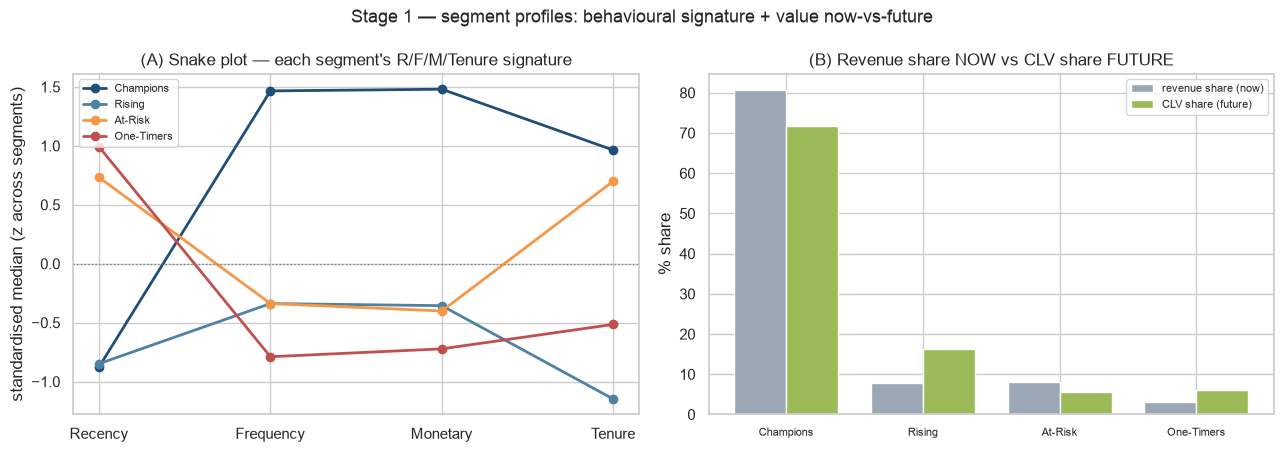

In [3]:
feats = segments.CLUSTER_FEATURES
med = df.groupby("segment", observed=True)[feats].median()
z = (med - med.mean()) / med.std()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for s in ORDER:
    ax[0].plot(feats, z.loc[s], marker="o", lw=2, color=COLORS[s], label=NAMES[s])
ax[0].axhline(0, color="grey", ls=":", lw=1)
ax[0].set_ylabel("standardised median (z across segments)")
ax[0].set_title("(A) Snake plot — each segment's R/F/M/Tenure signature")
ax[0].legend(fontsize=8)
x = np.arange(4); w = 0.38
ax[1].bar(x - w / 2, prof.loc[ORDER, "rev_share_pct"], w, label="revenue share (now)", color="#9aa7b4")
ax[1].bar(x + w / 2, prof.loc[ORDER, "clv_share_pct"], w, label="CLV share (future)", color="#9bbb59")
ax[1].set_xticks(x); ax[1].set_xticklabels([NAMES[s] for s in ORDER], fontsize=8)
ax[1].set_ylabel("% share"); ax[1].set_title("(B) Revenue share NOW vs CLV share FUTURE")
ax[1].legend(fontsize=8)
fig.suptitle("Stage 1 — segment profiles: behavioural signature + value now-vs-future", fontsize=13)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "segment_profiles.png"), dpi=150, bbox_inches="tight")
plt.show()

## Stage 2 — are the personas real? Three tiers of evidence (doc 13 §2)

Testing on the clustering features is near-circular, so evidence comes in tiers: (A) separation on
the clustering features (diagnostic), (B) multivariate classifier separability, (C) external
variables the clustering NEVER saw (the gold standard).

Tier A effect sizes (clustering features):
                   H  eta2_H
feature                    
Frequency  4971.550   0.850
Monetary   4076.508   0.697
Tenure     3072.189   0.525
Recency    2803.371   0.479

Tier B classifier CV accuracy = 0.984 ± 0.004 (majority baseline 0.276)


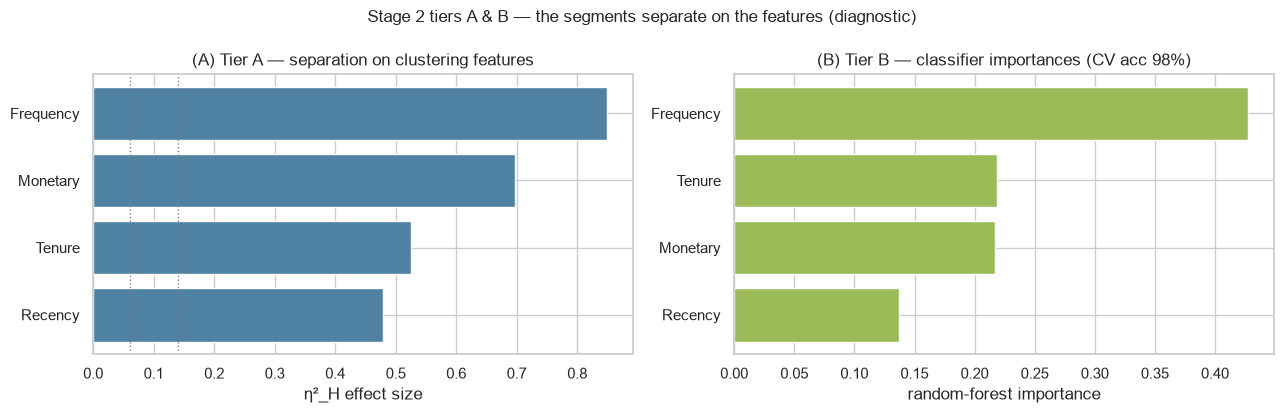

In [4]:
# Tier A — Kruskal-Wallis effect size per clustering feature (η²_H, not p-values at n≈5,900).
tierA = segments.kruskal_effect_sizes(df, feats)
# Tier B — classifier separability.
tierB = segments.classifier_separation(df)
print("Tier A effect sizes (clustering features):\n", tierA.round(3).to_string())
print(f"\nTier B classifier CV accuracy = {tierB['cv_accuracy']:.3f} ± {tierB['cv_std']:.3f} "
      f"(majority baseline {tierB['baseline']:.3f})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].barh(tierA.index[::-1], tierA["eta2_H"][::-1], color="#4f81a3")
for thr, lab in [(0.14, "large"), (0.06, "medium")]:
    ax[0].axvline(thr, color="grey", ls=":", lw=1)
ax[0].set_xlabel("η²_H effect size"); ax[0].set_title("(A) Tier A — separation on clustering features")
ax[1].barh(tierB["importances"].index[::-1], tierB["importances"].values[::-1], color="#9bbb59")
ax[1].set_xlabel("random-forest importance")
ax[1].set_title(f"(B) Tier B — classifier importances (CV acc {tierB['cv_accuracy']:.0%})")
fig.suptitle("Stage 2 tiers A & B — the segments separate on the features (diagnostic)", fontsize=12.5)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "validation_internal.png"), dpi=150, bbox_inches="tight")
plt.show()

**Caveat (honest):** Tiers A & B use the SAME features we clustered on, so strong separation is
expected — and Tier B's 98% is partly trivial (the one-timer split is literally `Frequency == 1`).
These confirm the segments are clean and separable, but they are NOT proof of "real". That comes next.

## Tier C — external variables (the gold standard, non-circular)

Do the segments ALSO differ on things the clustering never saw — **predicted CLV**, return rate,
country? And do they agree with independent rule-based RFM?

Tier C external effect sizes:
                    H  eta2_H
feature                     
clv         3631.893   0.621
ReturnRate   755.725   0.129

Cramér's V (segment vs Country)      = 0.093  (negligible -> geography does NOT discriminate)
Cramér's V (segment vs rule-RFM tier) = 0.611  | ARI = 0.399  (corroborates + refines)


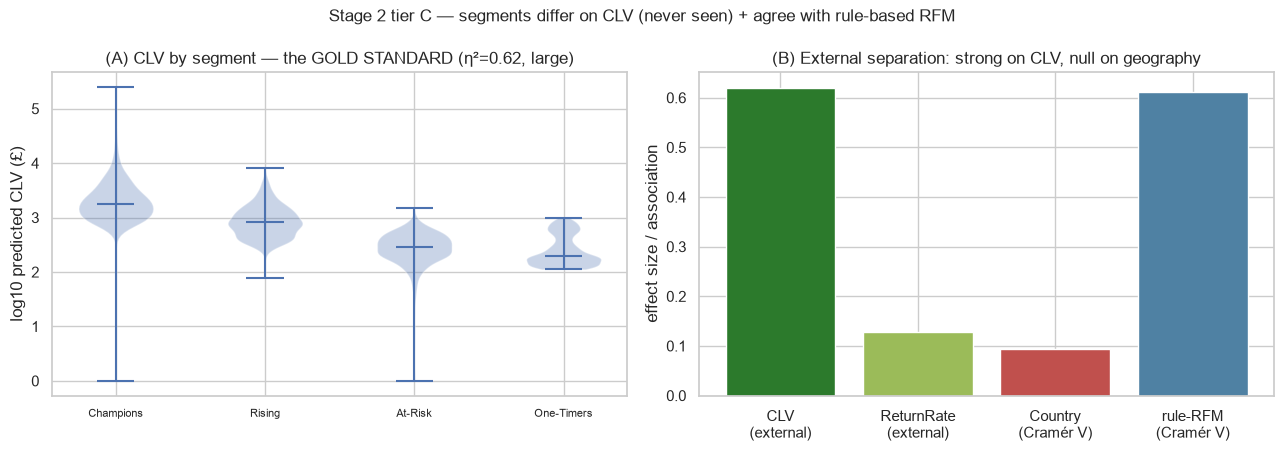

In [5]:
tierC = segments.kruskal_effect_sizes(df, ["clv", "ReturnRate"])
v_country = segments.cramers_v(df["segment"], df["Country"])
rfm = segments.rfm_quintile_segments(df)
rfm_tier = pd.qcut(rfm, 4, labels=False, duplicates="drop")
v_rfm = segments.cramers_v(df["segment"], rfm_tier)
ari_rfm = adjusted_rand_score(df["segment"].astype(str), rfm_tier)
print("Tier C external effect sizes:\n", tierC.round(3).to_string())
print(f"\nCramér's V (segment vs Country)      = {v_country:.3f}  (negligible -> geography does NOT discriminate)")
print(f"Cramér's V (segment vs rule-RFM tier) = {v_rfm:.3f}  | ARI = {ari_rfm:.3f}  (corroborates + refines)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
# (A) CLV by segment — the headline: a variable clustering never saw, ordered cleanly.
data = [np.log10(df.loc[df["segment"] == s, "clv"].clip(lower=1)) for s in ORDER]
parts = ax[0].violinplot(data, showmedians=True)
ax[0].set_xticks(range(1, 5)); ax[0].set_xticklabels([NAMES[s] for s in ORDER], fontsize=8)
ax[0].set_ylabel("log10 predicted CLV (£)")
ax[0].set_title(f"(A) CLV by segment — the GOLD STANDARD (η²={tierC.loc['clv','eta2_H']:.2f}, large)")
# (B) external effect sizes + agreements
labels = ["CLV\n(external)", "ReturnRate\n(external)", "Country\n(Cramér V)", "rule-RFM\n(Cramér V)"]
vals = [tierC.loc["clv", "eta2_H"], tierC.loc["ReturnRate", "eta2_H"], v_country, v_rfm]
cols = ["#2c7a2c", "#9bbb59", "#c0504d", "#4f81a3"]
ax[1].bar(labels, vals, color=cols)
ax[1].set_ylabel("effect size / association")
ax[1].set_title("(B) External separation: strong on CLV, null on geography")
fig.suptitle("Stage 2 tier C — segments differ on CLV (never seen) + agree with rule-based RFM", fontsize=12)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "validation_external.png"), dpi=150, bbox_inches="tight")
plt.show()

## Secret-twins check — does any segment PAIR collapse? (Cliff's delta)

If two segments are small on ALL features, they are the same group and K is too high (doc 13).

In [6]:
pairs = [(a, b) for i, a in enumerate(ORDER) for b in ORDER[i + 1:]]
twins = pd.DataFrame(
    {f: {f"{NAMES[a]} vs {NAMES[b]}": round(segments.cliffs_delta(
        df.loc[df.segment == a, f], df.loc[df.segment == b, f]), 2) for a, b in pairs}
     for f in feats})
print("Cliff's delta per feature, each segment pair (|δ|>0.47 = large):")
print(twins.to_string())
print("\nmax |δ| per pair (a pair small on ALL features = secret twins):")
print(twins.abs().max(axis=1).round(2).to_string())

Cliff's delta per feature, each segment pair (|δ|>0.47 = large):
                         Recency  Frequency  Monetary  Tenure
Champions vs Rising        -0.08       0.91      0.91    0.96
Champions vs At-Risk       -0.82       0.93      0.94    0.25
Champions vs One-Timers    -0.78       1.00      0.99    0.75
Rising vs At-Risk          -0.82      -0.00      0.10   -0.95
Rising vs One-Timers       -0.77       1.00      0.77   -0.23
At-Risk vs One-Timers      -0.11       1.00      0.73    0.66

max |δ| per pair (a pair small on ALL features = secret twins):
Champions vs Rising        0.96
Champions vs At-Risk       0.94
Champions vs One-Timers    1.00
Rising vs At-Risk          0.95
Rising vs One-Timers       1.00
At-Risk vs One-Timers      1.00


---
**Result — the personas are VALIDATED.** They separate cleanly on the clustering features (Tier A
large effect sizes; Tier B 98% classifier) and — the non-circular proof — **differ strongly on
predicted CLV (η²≈0.62), a variable the clustering never saw**, while agreeing with independent
rule-based RFM (Cramér's V≈0.61). Honest nulls reported: geography does NOT discriminate (V≈0.09),
and no segment pair collapses (no secret twins → K=3 is not too high). **Next:** `06b` — the segment
× CLV action grid, recommendations, and success criteria (docs 12, 14).